In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from sklearn.metrics import classification_report, confusion_matrix



In [ ]:
import os


os.environ["KAGGLE_USERNAME"] = "input your kaggle username"
os.environ["KAGGLE_KEY"] = "input your kaggle key"


!kaggle datasets download -d aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented


!unzip -q alzheimers-multiclass-dataset-equal-and-augmented.zip -d /content/alz_dataset
!ls -R /content/alz_dataset | grep demented -i -m 5

Dataset URL: https://www.kaggle.com/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
License(s): apache-2.0
 97% 386M/398M [00:00<00:00, 480MB/s]
100% 398M/398M [00:00<00:00, 533MB/s]
MildDemented
ModerateDemented
NonDemented
VeryMildDemented
/content/alz_dataset/combined_images/MildDemented:


In [ ]:

DATASET_PATH = '/content/alz_dataset/combined_images'


import os
os.makedirs('my_dementia_model_results', exist_ok=True)


datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)


train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    subset='training',
    shuffle=True,
    seed=42
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    subset='validation',
    shuffle=False,
    seed=42
)


print(f"Total images:    {train_data.samples + val_data.samples}")
print(f"Training set:    {train_data.samples}")
print(f"Validation set:  {val_data.samples}")
print(f"Class Mapping:   {train_data.class_indices}")

Found 35200 images belonging to 4 classes.
Found 8800 images belonging to 4 classes.
Total images:    44000
Training set:    35200
Validation set:  8800
Class Mapping:   {'MildDemented': 0, 'ModerateDemented': 1, 'NonDemented': 2, 'VeryMildDemented': 3}


In [ ]:

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))


base_model.trainable = False


model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax', dtype='float32') # 4 classes output
])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:

metrics = [
    'accuracy',
    tf.keras.metrics.SparseCategoricalAccuracy(name='sparse_acc')
]

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=metrics
)


In [ ]:

phase1_callbacks = [

    callbacks.ModelCheckpoint(
        'my_dementia_model_results/best_weights_phase1.h5',
        save_best_only=True,
        monitor='val_loss'
    ),

    callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),

    callbacks.CSVLogger('my_dementia_model_results/training_log_phase1.csv')
]

print("Starting Phase 1: Training the Classification Head...")
history_phase1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=phase1_callbacks
)

Starting Phase 1: Training the Classification Head...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.5244 - loss: 1.0873 - sparse_acc: 0.5244

1100/1100 ━━━━━━━━━━━━━━━━━━━━ 154s 122ms/step - accuracy: 0.5244 - loss: 1.0872 - sparse_acc: 0.5244 - val_accuracy: 0.6684 - val_loss: 0.7609 - val_sparse_acc: 0.6684
Epoch 2/10
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.6476 - loss: 0.7891 - sparse_acc: 0.6476

1100/1100 ━━━━━━━━━━━━━━━━━━━━ 136s 123ms/step - accuracy: 0.6476 - loss: 0.7890 - sparse_acc: 0.6476 - val_accuracy: 0.6988 - val_loss: 0.6893 - val_sparse_acc: 0.6988
Epoch 3/10
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.6939 - loss: 0.7004 - sparse_acc: 0.6939

1100/1100 ━━━━━━━━━━━━━━━━━━━━ 136s 124ms/step - accuracy: 0.6939 - loss: 0.7004 - sparse_acc: 0.6939 - val_accuracy: 0.7592 - val_loss: 0.5740 - val_sparse_acc: 0.7592
Epoch 4/10
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.7240 - loss: 0.6385 - sparse_acc: 0.7240

1100/1100 ━━━━━━━━━━━━━━━━━━━━ 136s 124ms/step - accuracy: 0.7240 - loss: 0.6385 - sparse_acc: 0.7240 - val_accuracy: 0.7665 - val_loss: 0.5481 - val_sparse_acc: 0.7665
Epoch 5/10
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.7508 - loss: 0.5933 - sparse_acc: 0.7508

1100/1100 ━━━━━━━━━━━━━━━━━━━━ 137s 124ms/step - accuracy: 0.7508 - loss: 0.5933 - sparse_acc: 0.7508 - val_accuracy: 0.7931 - val_loss: 0.4988 - val_sparse_acc: 0.7931
Epoch 6/10
 653/1100 ━━━━━━━━━━━━━━━━━━━━ 44s 99ms/step - accuracy: 0.7675 - loss: 0.5474 - sparse_acc: 0.7675

In [ ]:

base_model.trainable = True


for layer in base_model.layers[:140]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', 'sparse_categorical_accuracy']
)


phase2_callbacks = [
    callbacks.ModelCheckpoint('my_dementia_model_results/best_weights_final.keras', save_best_only=True, monitor='val_loss'),
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7),
    callbacks.CSVLogger('my_dementia_model_results/training_log_phase2.csv', append=True)
]

print("Starting Phase 2: Surgical Fine-Tuning (Stable Mode)...")
history_phase2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=phase2_callbacks
)

Starting Phase 2: Surgical Fine-Tuning (Stable Mode)...
Epoch 1/20
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 104s 70ms/step - accuracy: 0.5559 - loss: 6.8642 - sparse_categorical_accuracy: 0.5559 - val_accuracy: 0.6087 - val_loss: 2.0616 - val_sparse_categorical_accuracy: 0.6087 - learning_rate: 1.0000e-05
Epoch 2/20
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 68s 62ms/step - accuracy: 0.6995 - loss: 1.2475 - sparse_categorical_accuracy: 0.6995 - val_accuracy: 0.7053 - val_loss: 0.8392 - val_sparse_categorical_accuracy: 0.7053 - learning_rate: 1.0000e-05
Epoch 3/20
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 83s 76ms/step - accuracy: 0.7388 - loss: 0.7746 - sparse_categorical_accuracy: 0.7388 - val_accuracy: 0.7317 - val_loss: 0.6480 - val_sparse_categorical_accuracy: 0.7317 - learning_rate: 1.0000e-05
Epoch 4/20
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 66s 59ms/step - accuracy: 0.7649 - loss: 0.6428 - sparse_categorical_accuracy: 0.7649 - val_accuracy: 0.6997 - val_loss: 1.0411 - val_sparse_categorical_accuracy: 0.6997 - learning_

Calculating final predictions...
275/275 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step

  FINAL CLASSIFICATION REPORT
                  precision    recall  f1-score   support

    MildDemented       0.92      0.93      0.92      2000
ModerateDemented       0.99      1.00      0.99      2000
     NonDemented       0.88      0.94      0.91      2560
VeryMildDemented       0.92      0.84      0.88      2240

        accuracy                           0.93      8800
       macro avg       0.93      0.93      0.93      8800
    weighted avg       0.93      0.93      0.92      8800



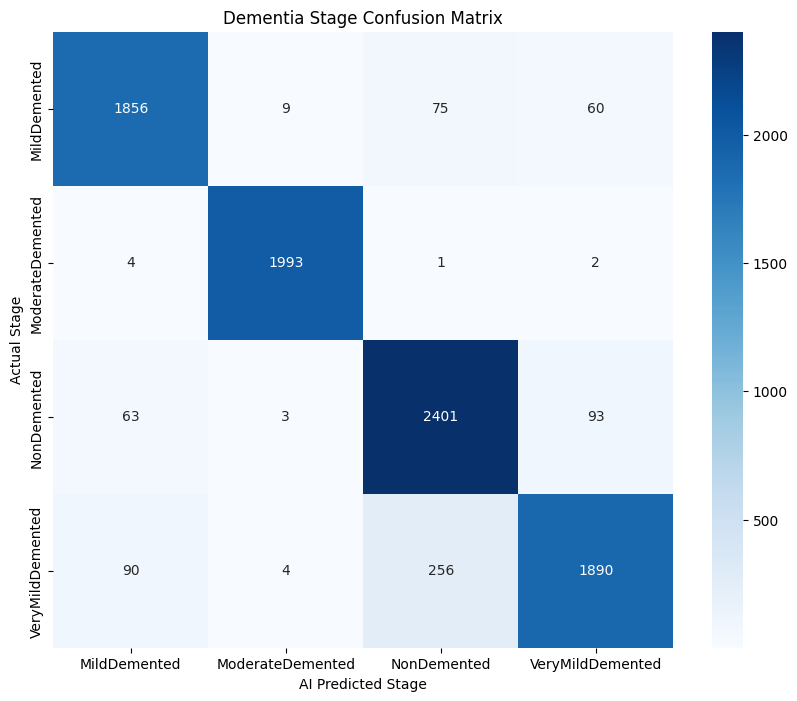


Final Overall AUC Score: 0.9920


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


print("Calculating final predictions...")

val_data.reset()
y_pred_probs = model.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_data.classes
class_names = list(val_data.class_indices.keys())


print("\n" + "="*30)
print("  FINAL CLASSIFICATION REPORT")
print("="*30)
print(classification_report(y_true, y_pred, target_names=class_names))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Dementia Stage Confusion Matrix')
plt.ylabel('Actual Stage')
plt.xlabel('AI Predicted Stage')
plt.show()


auc_val = roc_auc_score(y_true, y_pred_probs, multi_class='ovr')
print(f"\nFinal Overall AUC Score: {auc_val:.4f}")

In [ ]:
from google.colab import files


model.save('alzheimers_resnet50_v1.keras')


!zip -r clinical_results.zip /content/my_dementia_model_results


files.download('alzheimers_resnet50_v1.keras')
files.download('clinical_results.zip')

print("Downloads started. You've successfully built a high-performing medical AI!")

  adding: content/my_dementia_model_results/ (stored 0%)
  adding: content/my_dementia_model_results/best_weights_final.keras (deflated 8%)
  adding: content/my_dementia_model_results/best_weights_phase1.h5 (deflated 8%)
  adding: content/my_dementia_model_results/training_log_phase1.csv (deflated 61%)
  adding: content/my_dementia_model_results/training_log_phase2.csv (deflated 65%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads started. You've successfully built a high-performing medical AI!
